In [14]:
import numpy as np
import math
import configparser
import scipy
from scipy.constants import h       # Planck constant
from scipy.constants import hbar    # reduced Planck constant
from scipy.constants import k       # Boltzmann constant
from scipy.constants import N_A     # Avogadro number
from scipy.constants import e       # elementary charge
from scipy.constants import m_e     # mass of electron
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy import integrate
from scipy.integrate import simpson as simps
from scipy.integrate import trapezoid as trapz
import scipy.stats as stats
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import ticker
from matplotlib.ticker import LinearLocator, FixedLocator, MaxNLocator, MultipleLocator, EngFormatter, AutoMinorLocator
import csv
import time
import random
import pandas as pd

### Analytical Model for computing the two-channel based lattice thermal conductivity

omega shape: (201,)
Average SoS =  1601.3829497943993
Theta =  171.32118539999976
Ioffe–Regel freq =  0.9118454607244296  THz
C1 =  11.805  x 10^-16
A  =  0.015
C3 =  15.423  x 10^-40
P  =  0.387
unc_C1 =  0.284  x 10^-16
unc_A  =  0.002
unc_C3 =  1.848  x 10^-40
unc_P  =  0.007


/tmp/ipykernel_201870/1515788514.py:8: RuntimeWarning: overflow encountered in exp
  return x**2 * np.exp(x) * (np.exp(x) - 1)**(-2)
/tmp/ipykernel_201870/1515788514.py:8: RuntimeWarning: invalid value encountered in multiply
  return x**2 * np.exp(x) * (np.exp(x) - 1)**(-2)


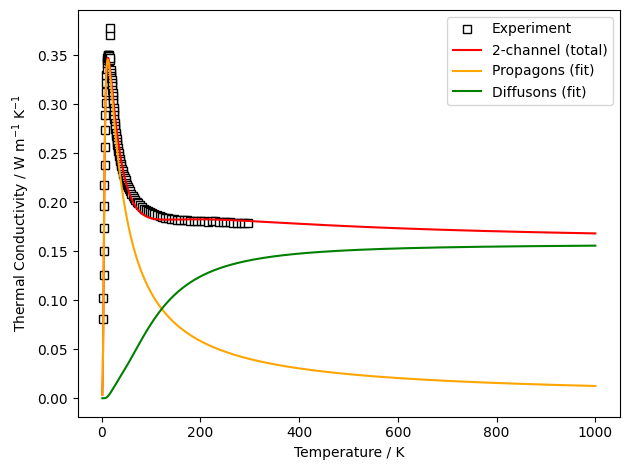

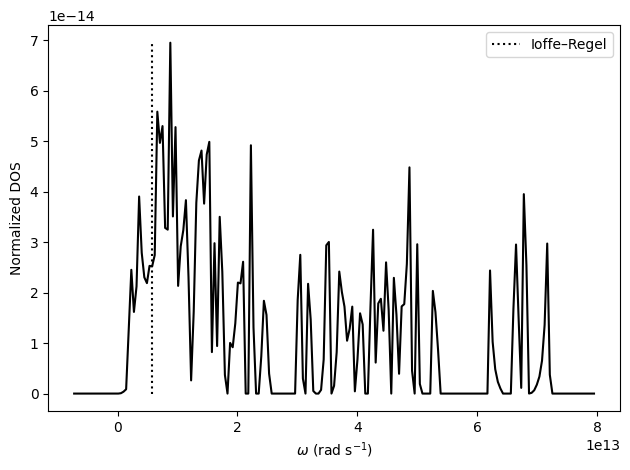

In [26]:

def HarmonicVs(vTrans, vLong):
    """Harmonic mean of transverse/longitudinal sound speeds."""
    return (3 * (vLong**(-3) + 2 * vTrans**(-3))**(-1))**(1/3)

def C_omega(angular_freq, Temp):
    """Spectral heat capacity per mode."""
    x = (hbar * angular_freq) / (k * (Temp + 1e-10))
    return x**2 * np.exp(x) * (np.exp(x) - 1)**(-2)

def omega_IR(n, vs, N):
    """Ioffe–Regel frequency (rad/s) for partitioning DOS into propagons/diffusons."""
    return (6 * n * np.pi**2)**(1/3) * vs * N**(-1/3)


def kappa_2ch(Temp, C1, A, C3, P):
    """
    Total lattice kappa (propagons + diffusons).
    - Propagons: 1/tau = C1*1e-16*ω^2*T + A*ω + C3*1e-40*ω^4
    - Diffusons: ~ P*ω (Allen-Feldman-like)
    Uses global arrays: omega, DOS, n, vs, N
    """
    w_IR = omega_IR(n, vs, N)
    prop_mask = omega < w_IR
    diff_mask = ~prop_mask

    kappa_tot = []
    for T in Temp:
        inv_tau = (C1 * 1e-16 * omega[prop_mask]**2 * T) + (A * omega[prop_mask]) + (C3 * 1e-40 * omega[prop_mask]**4)
        kappa_pr_omega = DOS[prop_mask] * C_omega(omega[prop_mask], T) * vs**2 / (inv_tau + 1e-300)
        kappa_diff_omega = DOS[diff_mask] * C_omega(omega[diff_mask], T) * P * omega[diff_mask]

        kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[prop_mask])
        kappa_diff = (1/np.pi) * n**(1/3) * k * trapz(kappa_diff_omega, omega[diff_mask])
        kappa_tot.append(kappa_pr + kappa_diff)

    return np.array(kappa_tot)


def both_kappas(Temp, C1, A, C3, P):
    """Return arrays of propagon and diffuson kappas; also save CSV."""
    w_IR = omega_IR(n, vs, N)
    prop_mask = omega < w_IR
    diff_mask = ~prop_mask

    kappa_tot = []
    prop = []
    diff = []

    for T in Temp:
        inv_tau = (C1 * 1e-16 * omega[prop_mask]**2 * T) + (A * omega[prop_mask]) + (C3 * 1e-40 * omega[prop_mask]**4)
        kappa_pr_omega = DOS[prop_mask] * C_omega(omega[prop_mask], T) * vs**2 / (inv_tau + 1e-300)
        kappa_diff_omega = DOS[diff_mask] * C_omega(omega[diff_mask], T) * P * omega[diff_mask]

        kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[prop_mask])
        kappa_diff = (1/np.pi) * n**(1/3) * k * trapz(kappa_diff_omega, omega[diff_mask])

        prop.append(kappa_pr)
        diff.append(kappa_diff)
        kappa_tot.append(kappa_pr + kappa_diff)

    df = pd.DataFrame({
        'T_K': Temp,
        'kappa_prop': prop,
        'kappa_diff': diff,
        'kappa_total': kappa_tot
    })
    df.to_csv('kappa_pd.csv', index=False)

    return np.array(prop), np.array(diff)

# --- DOS file (freq in THz, DOS unnormalized) ---
dat = np.loadtxt('total_dos.dat')
freq = dat[:, 0]                          # THz
DOS  = dat[:, 1]                          # arbitrary units (unnormalized)

omega = 2 * np.pi * freq * 1e12           # rad/s
print("omega shape:", omega.shape)

# Normalize DOS over omega
intDOS = trapz(DOS, omega)
DOS = DOS / intDOS

# --- Material properties ---
vl = 2871
vt = 1427
vs = HarmonicVs(vt, vl)                   # m/s, harmonic mean SoS
print("Average SoS = ", vs)

N = 60                                    # atoms per primitive cell
n = 4.64e28                               # number density, atoms/m^3

ThetaD = (hbar/k) * (6*np.pi**2*n)**(1/3) * vs
print("Theta = ", ThetaD)

# --- Experimental data file ---
data = pd.read_csv('sample_temp_conductivity.csv')  # columns: 'Tem', 'Conductivity'
T = data['Tem'].values
kappa_exp = data['Conductivity'].values


# Initial guess and bounds (tune as needed)
p0 = [1.60, 0.02, 0.5, 1.0]
bounds = ((0, 0.015, 0, 0), (np.inf, 0.1, np.inf, 1.0))

val, var = curve_fit(kappa_2ch, T[:-1], kappa_exp[:-1], p0=p0, bounds=bounds)
stdev = np.sqrt(np.diag(var))

print('Ioffe–Regel freq = ', omega_IR(n, vs, N) * 1e-12 / (2*np.pi), ' THz')
print('C1 = ', np.round(val[0],3), ' x 10^-16')
print('A  = ', np.round(val[1],3))
print('C3 = ', np.round(val[2],3), ' x 10^-40')
print('P  = ', np.round(val[3],3))
print('unc_C1 = ', np.round(stdev[0],3), ' x 10^-16')
print('unc_A  = ', np.round(stdev[1],3))
print('unc_C3 = ', np.round(stdev[2],3), ' x 10^-40')
print('unc_P  = ', np.round(stdev[3],3))


temp_fine = np.linspace(0.01, 1000, 1000)
kappa_fit_fine = kappa_2ch(temp_fine, *val)
k_pr_fine, k_diff_fine = both_kappas(temp_fine, *val)
#plot two-channel model
plt.figure()
# Experimental
plt.plot(T, kappa_exp, 'ks', markerfacecolor='w', label='Experiment')
# Total fit
plt.plot(temp_fine, kappa_fit_fine, 'r-', label='2-channel (total)')
# Channels
plt.plot(temp_fine, k_pr_fine, '-', color='orange', label='Propagons (fit)')
plt.plot(temp_fine, k_diff_fine, '-', color='green',  label='Diffusons (fit)')

plt.xlabel('Temperature / K')
plt.ylabel('Thermal Conductivity / W m$^{-1}$ K$^{-1}$')
plt.legend()
plt.tight_layout()
plt.savefig('AM_two-channel.tif', dpi=300)
plt.show()

#plot DOS

plt.figure()
plt.plot(omega, DOS, 'k-')
wIR = omega_IR(n, vs, N)
plt.plot([wIR, wIR], [0, np.max(DOS)], 'k:', label='Ioffe–Regel')
plt.xlabel(r'$\omega$ (rad s$^{-1}$)')
plt.ylabel('Normalized DOS')
plt.legend()
plt.tight_layout()
plt.show()


## Phonon-channel 

In [17]:
C1 =  11.805
A  =  0.015
C3 =  15.423
P  =  0.387
prop_total = []

Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T) + (A * omega[Prop_vals]) + (C3 * 1e-40 * omega[Prop_vals] ** 4)
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_total.append(kappa_pr)

## Phonon-channel subtracting Point-defect

In [19]:
prop_C1_A = []
Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T) + (A * omega[Prop_vals])
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_C1_A.append(kappa_pr)

## Phonon-channel subtracting Point-defect and boundary scattering

In [21]:
prop_C1 = []
Temp= list(range(2, 200, 2))
for T in Temp:
    inverse_tau = (C1 * 1e-16 * omega[Prop_vals] ** 2 * T)
    kappa_pr_omega = DOS[Prop_vals] * C_omega(omega[Prop_vals], T) * vs ** 2 * inverse_tau ** (-1)    
    kappa_pr = (1/3) * (3 * n * k) * trapz(kappa_pr_omega, omega[Prop_vals])
    prop_C1.append(kappa_pr)

## Phonon-channel (comparison plot) 

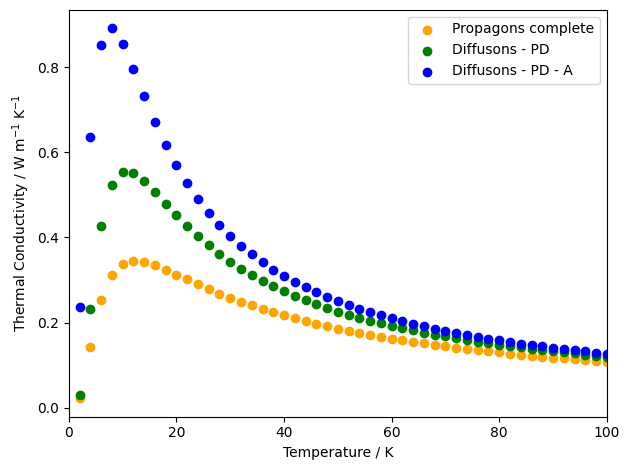

In [25]:
plt.scatter(Temp, prop_total, color='orange', label='Propagons complete')
plt.scatter(Temp, prop_C1_A, color='green',  label='Diffusons - PD')
plt.scatter(Temp, prop_C1, color='blue',  label='Diffusons - PD - A')
plt.xlim(0,100)
plt.xlabel('Temperature / K')
plt.ylabel('Thermal Conductivity / W m$^{-1}$ K$^{-1}$')
plt.legend()
plt.tight_layout()
plt.savefig('Comparison_phonon_channel', dpi=300)
plt.show()